## Building a Neural Network using Pytorch

I begin by importing the required libraries and the

data we will be training the model on from FashionMNIST.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (confusion_matrix, precision_score,
                             ConfusionMatrixDisplay)
from sklearn.metrics import accuracy_score, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import optuna

I am setting the random see for pytorch as 123 to

ensure that the output is the same each time.

In [2]:
torch.manual_seed(123)
np.random.seed(123)

Compose is a function used to chain multiple transformations together

below is ToTensor that converts input data into Pytorch Tensors

and Normalize that standardizes the tensor values using specified

mean and standard deviation values.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Next I am loading the FashionMNIST data set into the root directory.

I am downloading the whole training dataset with "train" = True and

the test dataset with "train" = False.

The total train data set size is 60,000 28x28 pixel images.

The total test data set size is 10,000 28x28 pixel images.

In [4]:
train_dataset = FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = FashionMNIST(root='./data', train=False, download=True, transform=transform)

print(f"Train data shape: {train_dataset.data.shape}")
print(f"Test data shape:  {test_dataset.data.shape}")

Train data shape: torch.Size([60000, 28, 28])
Test data shape:  torch.Size([10000, 28, 28])


I am now going to take a subset of the Train and Test data sets.

From the available data sets of 60K Training data samples and 10K

test samples we are going to take 20K and 4K respectively.

Using the DataLoader does the following to the sample datasets:

BatchSize = Groups individual samples into batches, of in this case 64.

It stacks 64 individual samples into a single tensor.

Shuffle it randomly reorders the indices before drawing batches

at the start of each epoch.


In [5]:
train_subset = Subset(train_dataset, list(range(20_000)))
test_subset  = Subset(test_dataset,  list(range(4_000)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_subset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_subset)}, Test: {len(test_subset)}")

Train: 20000, Test: 4000


I am now splitting the training data set between features (X) and labels (y).

I create an empty list for each category and then iterate through

the data set allocating each feature/label to the correct category.

For each image we flatten it to convert it into a 1 dimensional array.

Squeeze removes the channel dimension from the image tensor.

It's got a shape of [1, 28, 28] so it removes the 1 from the front.

X and y are then converted into numpy arrays ready for further processing.

In [6]:
def train_split():
    X_train = []
    y_train = []

    for image, label in train_loader:
        for img, lbl in zip(image, label):
            X_train.append(img.squeeze().flatten().numpy())
            y_train.append(lbl.item())

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    return X_train, y_train

X_train, y_train = train_split()

I am now splitting the test data into 2 sets in the same fashion.

In [7]:
def test_split():
    X_test = []
    y_test = []

    for image, label in test_loader:
        for img, lbl in zip(image, label):
            X_test.append(img.squeeze().flatten().numpy())
            y_test.append(lbl.item())

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    return X_test, y_test

X_test, y_test = test_split()

I am now converting X and y into Pytorch tensors using torch.tensor.

and specifying the data type for each tensor.

The data type ".long" below means it's a 64-bit signed integer.

In [8]:
X_tensor_train = torch.tensor(X_train, dtype=torch.float32)
y_tensor_train = torch.tensor(y_train, dtype=torch.long)

X_tensor_test = torch.tensor(X_test, dtype=torch.float32)
y_tensor_test = torch.tensor(y_test, dtype=torch.long)

Using the nn.Module class we're now able to define the architecture

of the MLP model. For the first hidden layer the ReLu

activation function is being applied to the output and

the softmax function is being applied to the output layer

to obtain class probabilities.

The forward method defines the forward pass of the network.

In [9]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.activation = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        #Forward pass through the network
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.fc2(x)
        x = self.softmax(x)

        return x

The input size is determined by the number of features.

The hidden size needs to be large enough to provide a model

complex enough to have a high accuracy, but not so large that

it overfits to the training data.

The output size is determined by the number of unique classes

in our dataset. With this data the output size is 10 nodes.

In [10]:
input_size = X_train.shape[1]

hidden_size = 64

output_size = len(np.unique(y_train))

output_size

10

The MLP model is initialized using the variables defined above.

We peform a forward pass through the MLP models to obtain the output.

We define the loss function using the CrossEntropyLoss function.

This compares the predicted output to the actual y labels.

The optimizer is configured using stochastic gradient descent

SGD, with a learning rate of 0.01. This is the rate the

algorithm updates to reduce the loss during training.

We initialize the gradient to zero using optomizer.zero_grad()

and perform the backward pass to compute the gradients

and update the weights using the optomizer step.

In [11]:
mlp = MLP(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.01)
epochs = 20

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_tensor_train)
    # Compare loss
    loss = criterion(outputs, y_tensor_train)
    # Zero gradients, backward pass, update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    #Print loss
    print(f'Epoch [{epoch+1}/{epochs}],Loss: {loss.item():.4f}')

Epoch [1/20],Loss: 2.3019
Epoch [2/20],Loss: 2.3017
Epoch [3/20],Loss: 2.3016
Epoch [4/20],Loss: 2.3015
Epoch [5/20],Loss: 2.3013
Epoch [6/20],Loss: 2.3012
Epoch [7/20],Loss: 2.3011
Epoch [8/20],Loss: 2.3009
Epoch [9/20],Loss: 2.3008
Epoch [10/20],Loss: 2.3006
Epoch [11/20],Loss: 2.3005
Epoch [12/20],Loss: 2.3004
Epoch [13/20],Loss: 2.3002
Epoch [14/20],Loss: 2.3001
Epoch [15/20],Loss: 2.2999
Epoch [16/20],Loss: 2.2998
Epoch [17/20],Loss: 2.2997
Epoch [18/20],Loss: 2.2995
Epoch [19/20],Loss: 2.2994
Epoch [20/20],Loss: 2.2992


The loss rates don't dramatically improve with each epoc

and appear to plateau at a loss of 2.3. The loss is

close to log(1/10) so given that we have 10 outputs

this is close to being a random chance prediction

which means it's not very effective at predicting the correct

result.

We are now going to make a prediction using the trained MLP model

without computing gradients. This reduces memory consumption and

improves inference speed. We achieve this by enclosing the prediction

code within a torch.no_grad() context manager that temporarily disables

the gradient calculation.

In [12]:
with torch.no_grad():
    outputs_test = mlp(X_tensor_test)
    _, predicted = torch.max(outputs_test, 1)

accuracy = accuracy_score(y_test, predicted)
print(f'Test Accuracy: {accuracy:.2f}')

Test Accuracy: 0.15


From my first run of the model I have got, as anticipated from the

loss score a poor Test Accuracy of 0.15.

We will now look at how the score can be improved.

The parameter I am going to change from the original run is

the learning rate as 0.01 is probably too low to achieve

the required accuracy in 20 epochs, it's not moving fast enough.

I am going to rerun the model with a learning rates

ranging from 0.0001 to 0.1 to see how increasing the learning

rate impacts the results. I am keeping all the other hyperparameters

constant.

In [13]:
mlp = MLP(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
learn_rates = [0.001, 0.01, 0.05, 0.1]
epochs = 20

results = {}

for lr in learn_rates:
    mlp = MLP(input_size, hidden_size, output_size)
    optimizer = optim.SGD(mlp.parameters(), lr=lr)

    # Each time I am updating the learning rate and training
    # the model using the X_tensor_train data set.
    print(f"\n--- Learning Rate: {lr} ---")
    for epoch in range(epochs):
        mlp.train()
        outputs = mlp(X_tensor_train)
        loss = criterion(outputs, y_tensor_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    # I am then calculating the accuracy of the model
    # with the updated learning rate.
    mlp.eval()
    with torch.no_grad():
        outputs_test = mlp(X_tensor_test)
        _, predicted = torch.max(outputs_test, 1)
        accuracy = accuracy_score(y_test, predicted)
        print(f'Accuracy for lr={lr}: {accuracy:.4f}')
        results[lr] = accuracy

print(f"\n{'LR':<12} {'Accuracy':<10}")
print("-" * 22)
for lr, acc in results.items():
    print(f"{lr:<12} {acc:.4f}")

print("-" * 22)
best_lr  = max(results, key=results.get)
best_acc = results[best_lr]
print(f"\nBest LR: {best_lr} gives  Accuracy: {best_acc:.4f}")


--- Learning Rate: 0.001 ---
Epoch [1/20], Loss: 2.3013
Epoch [2/20], Loss: 2.3013
Epoch [3/20], Loss: 2.3013
Epoch [4/20], Loss: 2.3013
Epoch [5/20], Loss: 2.3012
Epoch [6/20], Loss: 2.3012
Epoch [7/20], Loss: 2.3012
Epoch [8/20], Loss: 2.3012
Epoch [9/20], Loss: 2.3012
Epoch [10/20], Loss: 2.3011
Epoch [11/20], Loss: 2.3011
Epoch [12/20], Loss: 2.3011
Epoch [13/20], Loss: 2.3011
Epoch [14/20], Loss: 2.3011
Epoch [15/20], Loss: 2.3011
Epoch [16/20], Loss: 2.3010
Epoch [17/20], Loss: 2.3010
Epoch [18/20], Loss: 2.3010
Epoch [19/20], Loss: 2.3010
Epoch [20/20], Loss: 2.3010
Accuracy for lr=0.001: 0.1570

--- Learning Rate: 0.01 ---
Epoch [1/20], Loss: 2.3013
Epoch [2/20], Loss: 2.3011
Epoch [3/20], Loss: 2.3009
Epoch [4/20], Loss: 2.3007
Epoch [5/20], Loss: 2.3005
Epoch [6/20], Loss: 2.3003
Epoch [7/20], Loss: 2.3001
Epoch [8/20], Loss: 2.2999
Epoch [9/20], Loss: 2.2997
Epoch [10/20], Loss: 2.2995
Epoch [11/20], Loss: 2.2993
Epoch [12/20], Loss: 2.2991
Epoch [13/20], Loss: 2.2989
Epoch

Keeping all other hyperparameters constant and only increasing

the learning rate it's clear that increasing the lr up to 0.1

achieved an incremental improvement each time. 0.1 is the highest

and lr should generally go in neural networks as much higher and

you risk missing the target.

The highest accuracy achieved was 0.4688 with a lr of 0.1.

We can still aim to improve the model by tuning the other

hyperparameters and changing the activation function.

Below I am setting the learning rate to 0.1 and running

a confusion matrix and running some accuracy metrics.

In [14]:
mlp = MLP(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)
epochs = 20

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_tensor_train)
    # Compare loss
    loss = criterion(outputs, y_tensor_train)
    # Zero gradients, backward pass, update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
with torch.no_grad():
    outputs_test = mlp(X_tensor_test)
    _, predicted = torch.max(outputs_test, 1)

print("Accuracy:",  accuracy_score(y_test, predicted))
print("Precision:", precision_score(y_test, predicted, average='macro', zero_division=0))
print("Recall:",    recall_score(y_test, predicted,    average='macro'))
print("F1 Score:",  f1_score(y_test, predicted,        average='macro', zero_division=0))

Accuracy: 0.36075
Precision: 0.3866994507022617
Recall: 0.36314854430097165
F1 Score: 0.2658666259957617


To evaluate the breakdown of the models performance I have

calculated the above metrics.

Accuracy = The % of correction predictions that were made.

The above score means that 36.1% of its predictions were correct.

Precision = When a class is predicted how often it's right.

Precision = TP / (TP + FP) = 38.7%. The score is not great

a low precision means the model confuses similar looking classes.

Recall = For all the instances of the class how many were caught.

Recall = TP / (TP + FN) = 36.3%, fractionally worse than for Precision,

low recall means that real instances of similar classes get

misclassified.

F1 score = Harmonic average of the Precision and Recall.

The F1 score was 26.6%, showing that the model is struggling

to differentiate between the classes.

Below I have created a Confusion Matrix to identify the core

issues with the predictions.

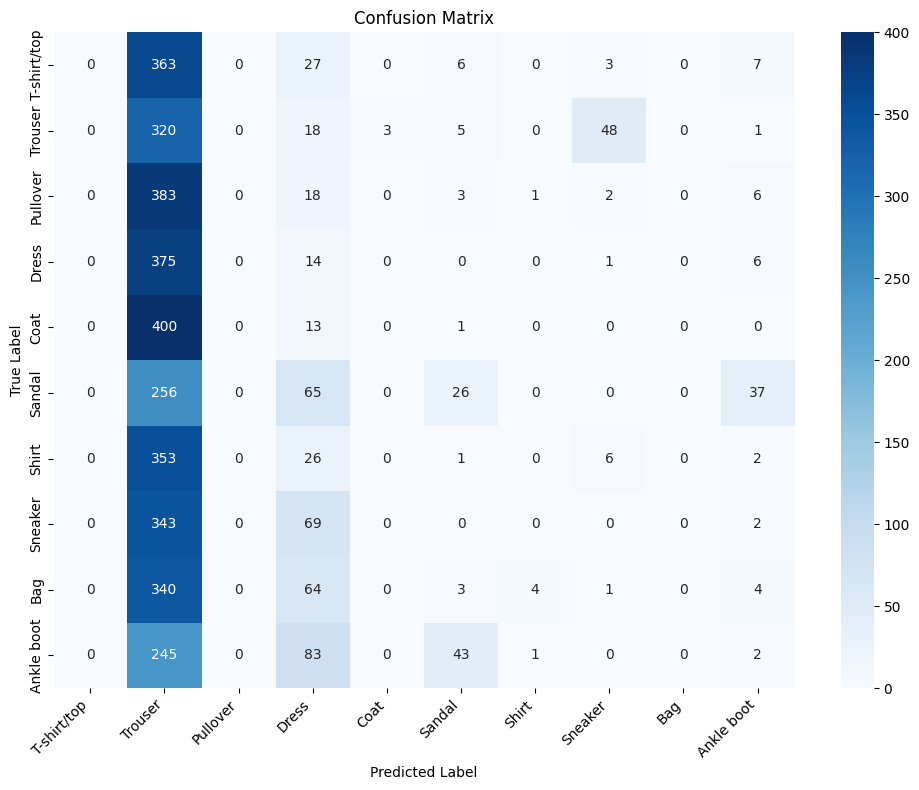

In [15]:
def evaluate_model(model, test_loader):
   model.eval()
   all_preds = []
   all_labels = []
   with torch.no_grad():
       for inputs, labels in test_loader:
           outputs = model(inputs)
           _, preds = torch.max(outputs, 1)
           all_preds.extend(preds.tolist())
           all_labels.extend(labels.tolist())
   return all_preds, all_labels
mlp = MLP(input_size, hidden_size, output_size)
preds, labels = evaluate_model(mlp, test_loader)
conf_matrix = confusion_matrix(labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',  
    cmap='Blues',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the 4000 predictions, 3836 of them are based in 3 classes.

The class with the highest number of predictions is Trouser

of the 3378 predictions in this class 320 were correct, 9.5%.

The worst performance on a percentage level was the sneakers

where the model predicted that 61 of the samples were that class and

got zero correct.

A library commonly used to optimize neural networks is the Optuna

library. The model automatically runs through combinations of

hyperparameters you define for it and tests the various configs

to find the best fit.

Below I am tuning the hyperparameters of:

Learning Rate: How big a step the model takes each time when moving

down the curve to find the zero gradient. Too little and it may not

find it in time, too much and it may overshoot.

Batch Size: Rather than feed the entire data set at once it's fed

into the model in batches. The size impacts the precision as too big

and it can overfit, too small and it can be too noisy.

Epochs: The number of runs through the total data set the model does.

Optimizer: The 2 optimizers we're looking at are SGD and Adam.

SGD = Stochastic Gradient Descent:

 new_weight = old_weight - (learning_rate × gradient)

Adam = Adaptive Moment Estimation:

Adam adapts the learning rate automatically for each weight

individually based on the history of gradients.

In [16]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, activation='ReLU'):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.activation = getattr(nn, activation)()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        return self.fc2(x)

def train_and_evaluate(model, train_loader, val_loader, optimizer, epochs):
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            preds = torch.argmax(model(images), dim=1)
            correct += (preds == labels).sum().item()

    return correct / len(val_loader.dataset)


def objective(trial):
    # Below are the list of hyperparameters to tune
    lr = trial.suggest_categorical('lr', [0.01, 0.05, 0.1])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs     = trial.suggest_int('epochs', 5, 50)
    optimizer  = trial.suggest_categorical('optimizer',  ['Adam', 'SGD'])
    hidden_size = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    activation  = trial.suggest_categorical('activation', ['ReLU','Tanh'])

    # Build model and loaders
    model = MLP(input_size, hidden_size, output_size, activation)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(test_dataset,   batch_size=batch_size)

    opt = getattr(torch.optim, optimizer)(model.parameters(), lr=lr)

    accuracy = train_and_evaluate(model, train_loader, val_loader, opt, epochs=epochs)
    return accuracy


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f"Best params: {study.best_params}")
print(f"Best value:  {study.best_value:.4f}")

[I 2026-05-04 21:04:04,292] A new study created in memory with name: no-name-a2a66b3b-9608-48c1-930e-9fabba205454
[I 2026-05-04 21:04:31,429] Trial 0 finished with value: 0.6706 and parameters: {'lr': 0.1, 'batch_size': 128, 'epochs': 7, 'optimizer': 'Adam', 'hidden_size': 64, 'activation': 'Tanh'}. Best is trial 0 with value: 0.6706.
[I 2026-05-04 21:06:06,573] Trial 1 finished with value: 0.8623 and parameters: {'lr': 0.01, 'batch_size': 128, 'epochs': 25, 'optimizer': 'Adam', 'hidden_size': 256, 'activation': 'ReLU'}. Best is trial 1 with value: 0.8623.
[I 2026-05-04 21:08:48,399] Trial 2 finished with value: 0.8785 and parameters: {'lr': 0.05, 'batch_size': 32, 'epochs': 47, 'optimizer': 'SGD', 'hidden_size': 64, 'activation': 'ReLU'}. Best is trial 2 with value: 0.8785.
[I 2026-05-04 21:11:26,733] Trial 3 finished with value: 0.8676 and parameters: {'lr': 0.1, 'batch_size': 64, 'epochs': 49, 'optimizer': 'SGD', 'hidden_size': 64, 'activation': 'ReLU'}. Best is trial 2 with value: 

Best params: {'lr': 0.05, 'batch_size': 32, 'epochs': 47, 'optimizer': 'SGD', 'hidden_size': 64, 'activation': 'ReLU'}
Best value:  0.8785


Optuna has gone through a number of different combinations and found

that using a learning rate of 0.05, batch size of 32, 47 epochs,

optimizer of SGD and hidden size of 64 achieved the highest accuracy

of 87.85%. This is above the 80% threshold we were looking to achieve

so we can use this config to run our model.


Using the parameters recommended above by the Optuna library

We now have the significantly improved accuracy of 86.025%.

The model also has a good balance of precision and recall

shown by the strong F1 score of 86.3%.

Optuna was running using a DataLoader that updates the weights

after every batch, where as the final run in original model

we were running wasn't. I've fixed this in the below code by

wrapping the final run in a DataLoader so the results

should be similar to what Optuna achieved.

In [19]:
hidden_size = 64
output_size = len(np.unique(y_train))
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_subset,  batch_size=32, shuffle=False)
X_train, y_train = train_split()
X_test, y_test = test_split()

X_tensor_train = torch.tensor(X_train, dtype=torch.float32)
y_tensor_train = torch.tensor(y_train, dtype=torch.long)
X_tensor_test = torch.tensor(X_test, dtype=torch.float32)
y_tensor_test = torch.tensor(y_test, dtype=torch.long)

mlp = MLP(input_size, hidden_size, output_size, activation='ReLU')
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.05)
epochs = 47

for epoch in range(epochs):
    mlp.train()
    for X_batch, y_batch in train_loader:   # ← this is what's missing
        optimizer.zero_grad()
        loss = criterion(mlp(X_batch), y_batch)
        loss.backward()
        optimizer.step()

mlp.eval()
with torch.no_grad():
    outputs_test = mlp(X_tensor_test)
    _, predicted = torch.max(outputs_test, 1)

print("Accuracy:", accuracy_score(y_test, predicted))
print("Precision:",
      precision_score(y_test, predicted, average='macro', zero_division=0))
print("Recall:", recall_score(y_test, predicted, average='macro'))
print("F1 Score:",
      f1_score(y_test, predicted, average='macro', zero_division=0))

Accuracy: 0.86025
Precision: 0.8688876557605149
Recall: 0.8611682857250414
F1 Score: 0.8629844514386524


As you can see from below, the model using the below tuned

hyperparameters has a much better accuracy in its predictions.

Even with the much improved performance the model still has

difficulty with predicting clothes similar in shape to shirts

and misclassifies pullovers, coats and t-shirts in some instances

as shirts.

The model performed best at identifying trousers. For the 385 times

it predicted an item was trousers it was correct 98% of the time and

of the total number of trouser items it captured 95% of them.

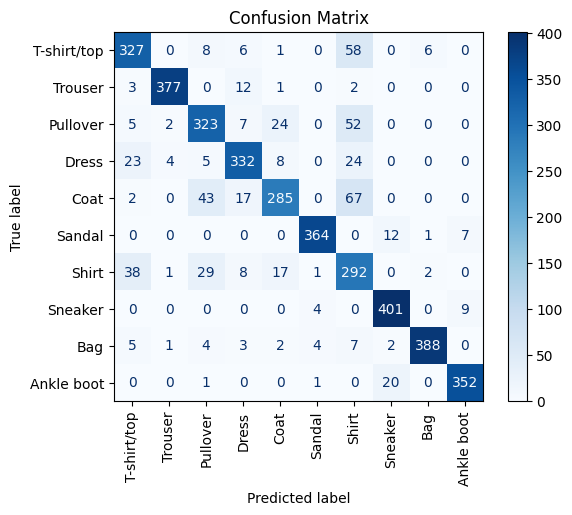

In [20]:
cm = confusion_matrix(y_test, predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('Confusion Matrix')
plt.show()